In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df=pd.read_csv('/Churn_Modelling.csv')

#Clean & Prepare the Data

In [ ]:
#Head To Check First 5 rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
#Tail to check Last 5 rows
print(df.tail())

      RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
9995       5       0.00              2          1               0   
9996      10   57369.61              1          1               1   
9997       7       0.00              1          0               1   
9998       3   75075.31              2          1               0   
9999       4  130142.79              1          1               0   

      EstimatedSalary  Exited  
9995         96270.64       0  
9996        101699.77       0  
9997         42085.5

In [ ]:
#Summary of a DataFrame.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [ ]:
#We Have TO drop irrelevant column like  RowNumber ,CustomerId And Surname as it does not effect our predicition
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [ ]:
# Confirm final shape & column types
print(df.head())
print(df.dtypes)

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int

In [ ]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

In [ ]:
df['Age'].mean()

np.float64(38.9218)

In [ ]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

#Encode Categorical Features

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Geography']=le.fit_transform(df['Geography'])

In [ ]:
df['Gender'].unique()

array([0, 1])

In [ ]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [ ]:
print(df.head())
print(df.shape)
print(df.dtypes)

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_1  Geography_2  
0               1        101348.88       1        False        False  
1               1        112542.58       0        False         True  
2               0        113931.57       1        False        False  
3               0         93826.63       0        False        False  
4               1         79084.10       0        False         True  
(10000, 12)
CreditScore          int64
Gender               int64
Age                  int64
Tenure               int

In [ ]:
df.rename(columns={'Geography_1':'Geography_Germany',
        'Geography_2':'Geography_Spain'}
          ,inplace=True)

In [ ]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


#Data Visualization

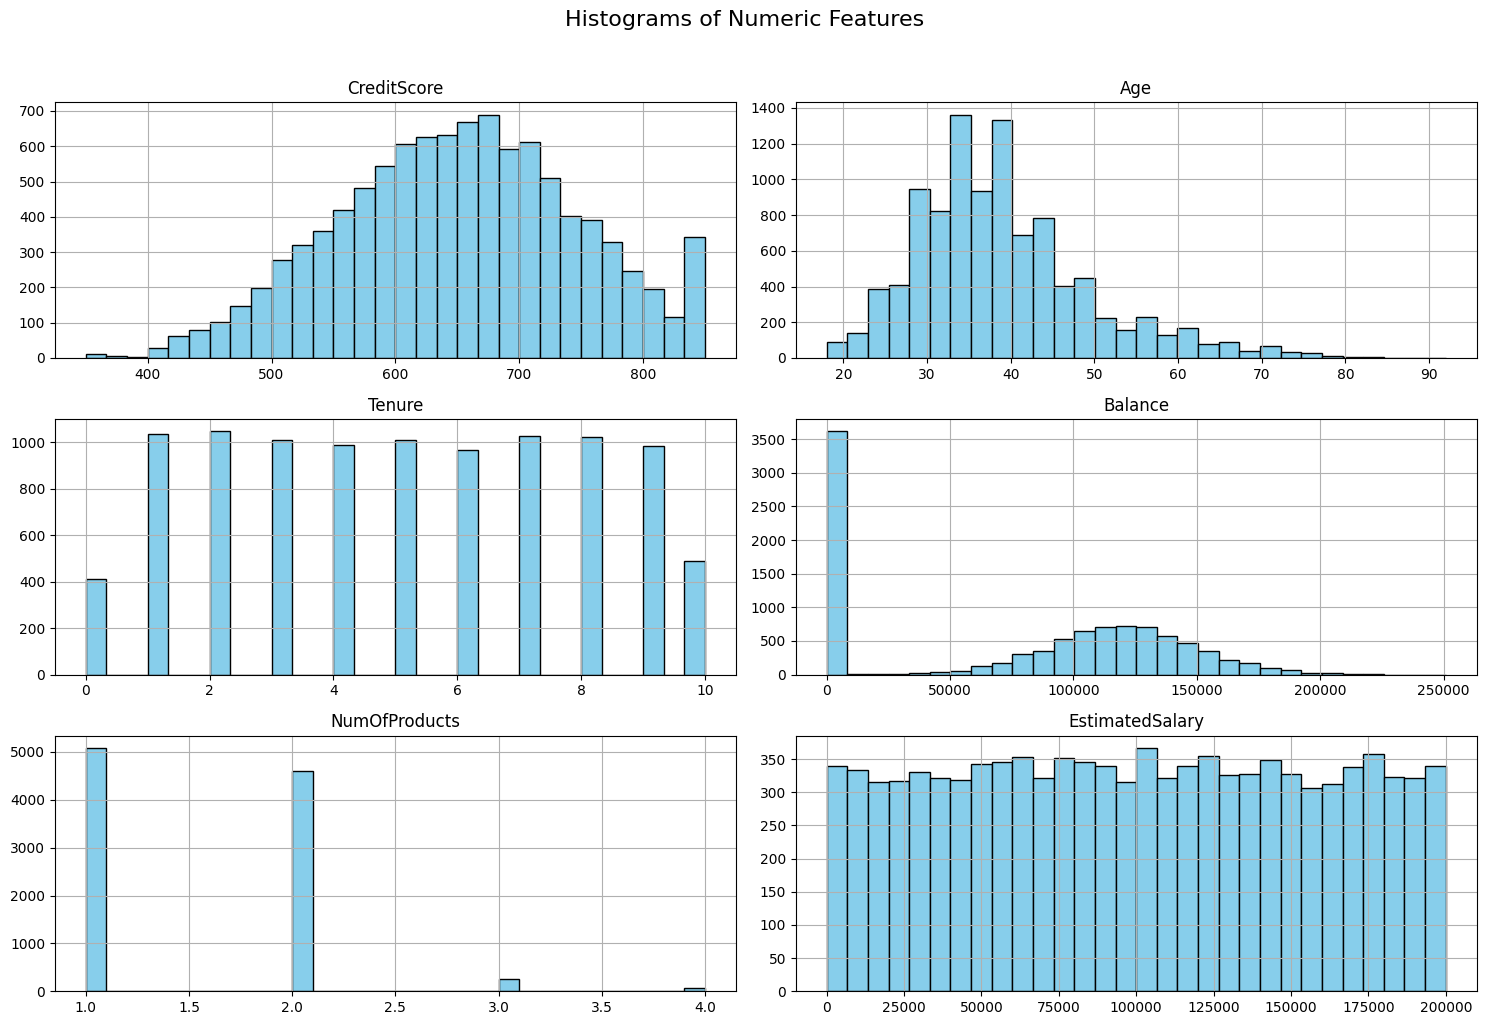

In [ ]:
numeric_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
df[numeric_columns].hist(figsize=(15, 10),bins=30,color='skyblue',edgecolor='black')
plt.suptitle('Histograms of Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

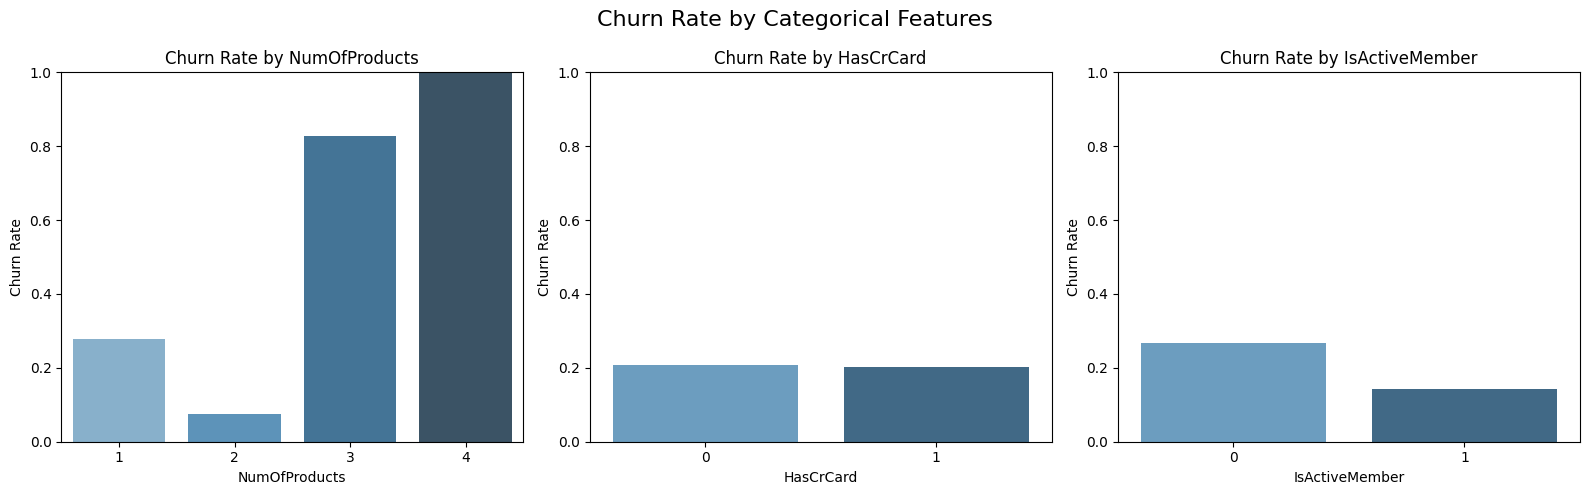

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Geography
geo_churn = df.groupby('Geography_Germany')['Exited'].mean()

cat_cols = ['Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

for ax, col in zip(axes.flatten(), ['NumOfProducts', 'HasCrCard', 'IsActiveMember']):
    churn_rate = df.groupby(col)['Exited'].mean().reset_index()
    sns.barplot(data=churn_rate, x=col, y='Exited', ax=ax,
                palette='Blues_d')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 1)

plt.suptitle('Churn Rate by Categorical Features', fontsize=16)
plt.tight_layout()
plt.show()

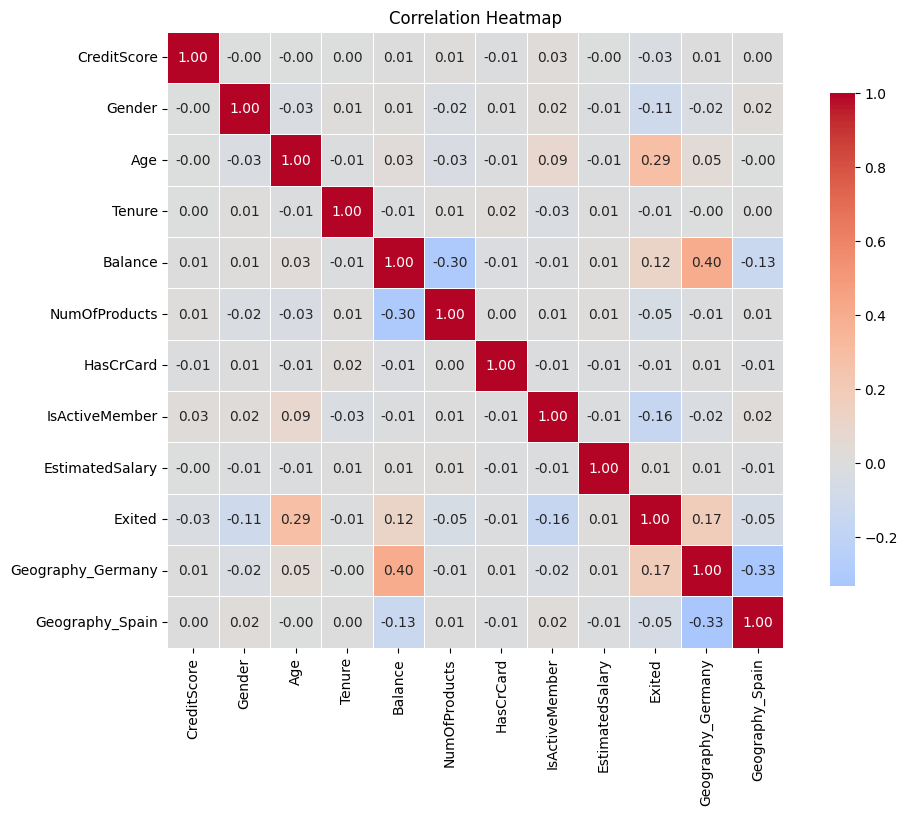

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True,          # show correlation values
            fmt='.2f',
            cmap='coolwarm',     # blue=negative, red=positive
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap')
plt.show()

#Train a Classification Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
x=df.drop(columns=['Exited'])
y=df['Exited']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#

In [ ]:
rf=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10,class_weight='balanced',n_jobs=-1)
rf.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred  = rf.predict(x_test)
y_proba = rf.predict_proba(x_test)[:, 1]

In [ ]:
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))



── Classification Report ──
              precision    recall  f1-score   support

      Stayed       0.92      0.89      0.90      1607
     Churned       0.60      0.67      0.63       393

    accuracy                           0.85      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.85      0.85      2000



Classification Report shows that our model is biased toward predicting “Stayed“                                                         

Reasons

>  1:Data imbalance

>




1:Data imbalance
2:Model prefers majority class

Reasons

>  1:Data imbalance

> Model Prefers majority class

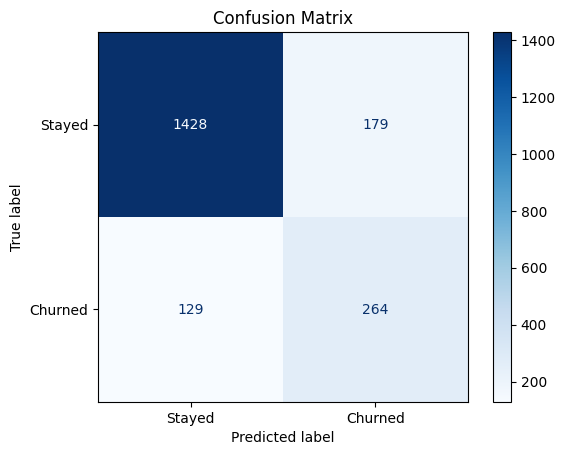

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

          Feature  Importance
              Age    0.322332
    NumOfProducts    0.209306
          Balance    0.116801
  EstimatedSalary    0.083048
      CreditScore    0.079298
   IsActiveMember    0.056586
           Tenure    0.045384
Geography_Germany    0.043415
           Gender    0.022607
        HasCrCard    0.010815
  Geography_Spain    0.010408


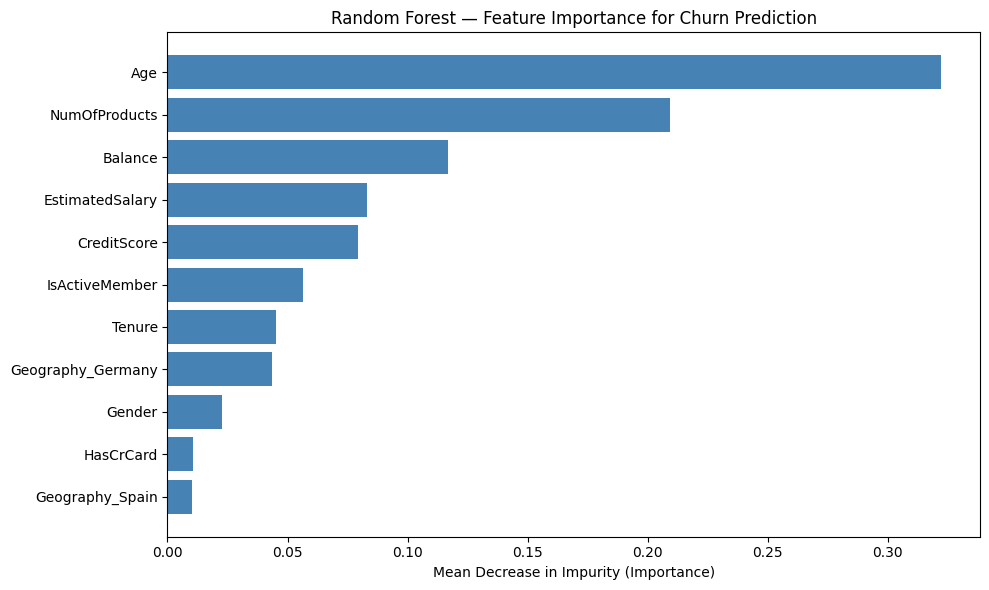

In [ ]:
# ── Step 4: Feature Importance ───────────────────────────────────
importances = rf.feature_importances_
feature_names = x.columns

# Create a sorted DataFrame
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feat_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color='steelblue')
plt.xlabel('Mean Decrease in Impurity (Importance)')
plt.title('Random Forest — Feature Importance for Churn Prediction')
plt.tight_layout()
plt.show()

##As Our Data is imbalanced so we have to add Smote and then train model


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
sm = SMOTE(random_state=42)
x_train_sm, y_train_sm = sm.fit_resample(x_train, y_train)


In [ ]:
rf_after = RandomForestClassifier(n_estimators=200, max_depth=10,
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_after.fit(x_train_sm, y_train_sm)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [ ]:
y_pred_after  = rf_after.predict(x_test)
y_proba_after = rf_after.predict_proba(x_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred_after, target_names=['Stayed', 'Churned']))


              precision    recall  f1-score   support

      Stayed       0.91      0.86      0.88      1607
     Churned       0.53      0.67      0.60       393

    accuracy                           0.82      2000
   macro avg       0.72      0.76      0.74      2000
weighted avg       0.84      0.82      0.83      2000



In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score

# Replace y_pred and y_proba with YOUR actual variable names from before SMOTE
comparison = pd.DataFrame({
    'Metric': ['Precision (Churned)', 'Recall (Churned)', 'F1 (Churned)', 'ROC-AUC'],
    'Before SMOTE': [
        f1_score(y_test, y_pred, average=None)[1],
        confusion_matrix(y_test, y_pred)[1,1] /
            confusion_matrix(y_test, y_pred)[1].sum(),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ],
    'After SMOTE': [
        f1_score(y_test, y_pred_after, average=None)[1],
        confusion_matrix(y_test, y_pred_after)[1,1] /
            confusion_matrix(y_test, y_pred_after)[1].sum(),
        f1_score(y_test, y_pred_after),
        roc_auc_score(y_test, y_proba_after)
    ]
})
comparison = comparison.set_index('Metric').round(4)
print(comparison.to_string())

                     Before SMOTE  After SMOTE
Metric                                        
Precision (Churned)        0.6316       0.5955
Recall (Churned)           0.6718       0.6743
F1 (Churned)               0.6316       0.5955
ROC-AUC                    0.8660       0.8504


In [140]:
# Install if not already available
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=4,   # handles imbalance (majority/minority = 7963/2037 ≈ 4)
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(x_train, y_train)

# Evaluate
y_pred_xgb  = xgb.predict(x_test)
y_proba_xgb = xgb.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=['Stayed', 'Churned']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")

# Compare RF vs XGBoost
comparison = pd.DataFrame({
    'Metric': ['Precision (Churned)', 'Recall (Churned)', 'F1 (Churned)', 'ROC-AUC'],
    'Random Forest': [
        f1_score(y_test, y_pred, average=None)[1],
        confusion_matrix(y_test, y_pred)[1,1] / confusion_matrix(y_test, y_pred)[1].sum(),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ],
    'XGBoost': [
        f1_score(y_test, y_pred_xgb, average=None)[1],
        confusion_matrix(y_test, y_pred_xgb)[1,1] / confusion_matrix(y_test, y_pred_xgb)[1].sum(),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_proba_xgb)
    ]
}).set_index('Metric').round(4)

print(comparison.to_string())

              precision    recall  f1-score   support

      Stayed       0.92      0.86      0.89      1607
     Churned       0.55      0.71      0.62       393

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.85      0.83      0.84      2000

ROC-AUC : 0.8565
F1 Score: 0.6179
                     Random Forest  XGBoost
Metric                                     
Precision (Churned)         0.6316   0.6179
Recall (Churned)            0.6718   0.7099
F1 (Churned)                0.6316   0.6179
ROC-AUC                     0.8660   0.8565


In [ ]:
I Tries Hard to Increase The Accuracy But I am unable to do so due to lack of time and resources